**Nobel Prize Data Analysis (1901–2016)**

This notebook analyzes the Nobel Prize dataset (1901–2016), focusing on gender trends,
country representation, and laureate age over time.
The dataset contains one row per
laureate per prize.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub

path = kagglehub.dataset_download("nobelfoundation/nobel-laureates")

print(os.listdir(path))

100%|██████████| 66.2k/66.2k [00:00<00:00, 24.8MB/s]

Extracting files...
['archive.csv']


In [3]:
file_path = os.path.join(path, "archive.csv")
df=pd.read_csv(file_path)
df.head()
df.sample(5)

,Year,Category,Prize,Motivation,Prize Share,Laureate ID,Laureate Type,Full Name,Birth Date,Birth City,Birth Country,Sex,Organization Name,Organization City,Organization Country,Death Date,Death City,Death Country
438,1972,Literature,The Nobel Prize in Literature 1972,"""for his writing which through its combination...",1/1,647,Individual,Heinrich Böll,1917-12-21,Cologne,Germany,Male,NaN,NaN,NaN,1985-07-16,Bornheim-Merten,West Germany (Germany)
53,1909,Medicine,The Nobel Prize in Physiology or Medicine 1909,"""for his work on the physiology, pathology and...",1/1,303,Individual,Emil Theodor Kocher,1841-08-25,Berne,Switzerland,Male,Berne University,Berne,Switzerland,1917-07-27,Berne,Switzerland
230,1945,Physics,The Nobel Prize in Physics 1945,"""for the discovery of the Exclusion Principle,...",1/1,50,Individual,Wolfgang Pauli,1900-04-25,Vienna,Austria,Male,Princeton University,"Princeton, NJ",United States of America,1958-12-15,Zurich,Switzerland
822,2006,Physics,The Nobel Prize in Physics 2006,"""for their discovery of the blackbody form and...",1/2,804,Individual,John C. Mather,1946-08-07,"Roanoke, VA",United States of America,Male,NASA Goddard Space Flight Center,"Greenbelt, MD",United States of America,NaN,NaN,NaN
171,1933,Medicine,The Nobel Prize in Physiology or Medicine 1933,"""for his discoveries concerning the role playe...",1/1,325,Individual,Thomas Hunt Morgan,1866-09-25,"Lexington, KY",United States of America,Male,California Institute of Technology (Caltech),"Pasadena, CA",United States of America,1945-12-04,"Pasadena, CA",United States of America


**Dataset**  **Overview**


In [4]:
print("Original shape:", df.shape)
df.info()
print(df.describe())

Original shape: (969, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Year                  969 non-null    int64 
 1   Category              969 non-null    object
 2   Prize                 969 non-null    object
 3   Motivation            881 non-null    object
 4   Prize Share           969 non-null    object
 5   Laureate ID           969 non-null    int64 
 6   Laureate Type         969 non-null    object
 7   Full Name             969 non-null    object
 8   Birth Date            940 non-null    object
 9   Birth City            941 non-null    object
 10  Birth Country         943 non-null    object
 11  Sex                   943 non-null    object
 12  Organization Name     722 non-null    object
 13  Organization City     716 non-null    object
 14  Organization Country  716 non-null    object
 15  Death Date    

**df.shape** tells us the total number of rows  and columns in the raw dataset.

**df.info() **shows each column's data type and how many non-null values it has, useful for spotting missing data early.

**df.describe()** gives a statistical summary of numeric columns
like Year and Age, showing min, max, and average values.


**Column types summary & select relevant columns**

In [32]:

print(df.dtypes.value_counts())
columns_needed=[
    'Year',
    'Category',
    'Motivation',
    'Full Name',
    'Birth Date',
    'Birth Country',
    'Sex'
]

df_clean = df[columns_needed].copy()
print("Shape after selecting columns: ", df_clean.shape)


df_clean['Decade'] = (df_clean['Year'] // 10) * 10
df_clean['Birth Date'] = pd.to_datetime(df_clean['Birth Date'], errors='coerce')

df_clean['Age'] = df_clean['Year'] - df_clean['Birth Date'].dt.year


bins = [ 15, 30, 60, 100]
labels = [ 'Youth', 'Adult', 'Senior']
df_clean['Age group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels)

object    16
int64      2
Name: count, dtype: int64
Shape after selecting columns:  (969, 7)


**Missing Values Analysis**

In [35]:
missing_percentage = (df.isna().sum() / len(df)) * 100
missing_percentage[missing_percentage > 0]


,0
Birth Date,2.992776
Birth City,2.889577
Organization Name,25.490196
Organization City,26.109391
Organization Country,26.109391
Death Date,36.326109
Death City,38.183695
Death Country,37.564499


Columns with a high missing percentage (like Motivation and Birth Country) are expected, not every laureate has complete records. We will fill these with placeholder values so
they don't cause errors in our analysis.

**Handle missing values**

In [34]:
df_clean['Birth Country'] = df_clean['Birth Country'].fillna('Unknown')
df_clean['Sex'] = df_clean['Sex'].fillna('Unknown')
df_clean['Motivation'] = df_clean['Motivation'].fillna('Not specified')

print("Missing values after filling:")
print(df_clean.isna().sum())

print("Shape:", df_clean.shape)

df.head()
df.info()

Missing values after filling:
Year              0
Category          0
Motivation        0
Full Name         0
Birth Date       31
Birth Country     0
Sex               0
Decade            0
Age              31
Age group        31
dtype: int64
Shape: (969, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Year                  969 non-null    int64 
 1   Category              969 non-null    object
 2   Prize                 969 non-null    object
 3   Motivation            969 non-null    object
 4   Prize Share           969 non-null    object
 5   Laureate ID           969 non-null    int64 
 6   Laureate Type         969 non-null    object
 7   Full Name             969 non-null    object
 8   Birth Date            940 non-null    object
 9   Birth City            941 non-null    object
 10  Birth Country         969 non-

**Nobel Prizes by Category**

Category
Medicine      227
Physics       222
Chemistry     194
Peace         130
Literature    113
Economics      83
Name: count, dtype: int64


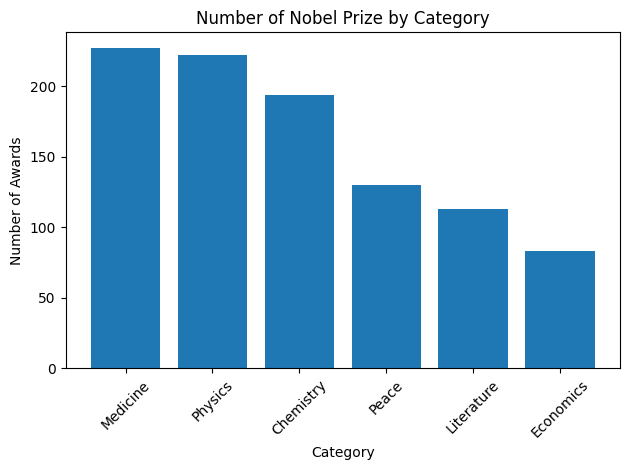

In [38]:
category_value=df_clean.Category.value_counts()
print(category_value)

plt.bar(category_value.index, category_value.values)
plt.title("Number of Nobel Prize by Category")
plt.xlabel("Category")
plt.ylabel("Number of Awards")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Medicine and Physics have the highest number of prizes awarded, while Economics has the
fewest, partly because the Economics prize was only introduced in 1969, much later than
the others.

**Nobel Prizes by Gender**

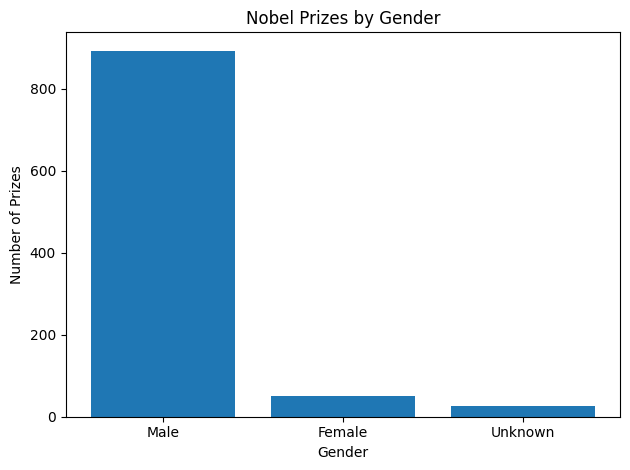

In [37]:
gender_counts = df_clean['Sex'].value_counts()
plt.bar(gender_counts.index, gender_counts.values)
plt.title("Nobel Prizes by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Prizes")
plt.tight_layout()
plt.show()

The vast majority of Nobel Prize winners have been male. This chart gives us the overall
picture, the following charts will break this down further over time and by category.

**Gender Distribution Over Decades**

Sex     Female   Male
Decade               
1900       3.0   54.0
1910       1.0   37.0
1920       2.0   52.0
1930       3.0   58.0
1940       3.0   39.0
1950       NaN   78.0
1960       3.0   73.0
1970       4.0  102.0
1980       4.0   92.0
1990       7.0   97.0
2000      12.0  124.0
2010       8.0   87.0


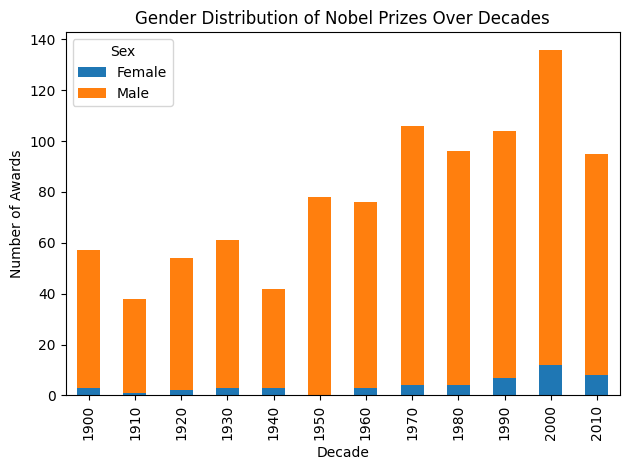

In [11]:
gender_decade = df_clean.groupby(['Decade', 'Sex']).size().unstack()
print(gender_decade)

gender_decade.plot(kind='bar', stacked=True)
plt.title("Gender Distribution of Nobel Prizes Over Decades")
plt.xlabel("Decade")
plt.ylabel("Number of Awards")
plt.tight_layout()
plt.show()

Each bar represents one decade. The stacked colors show how many prizes went to men vs
women in that decade. Notice how the female (orange) portion is almost invisible in early
decades and slowly grows over time.

**Female Laureates by Category**

Category
Peace         16
Literature    14
Medicine      12
Chemistry      4
Physics        2
Economics      2
Name: count, dtype: int64


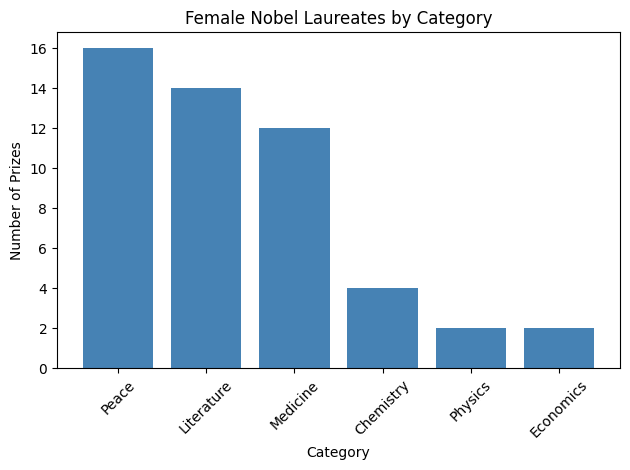

In [36]:
female_df = df_clean[df_clean['Sex']=='Female']
female_by_category = female_df['Category'].value_counts()
print(female_by_category)

plt.bar(female_by_category.index, female_by_category.values, color='steelblue')
plt.title("Female Nobel Laureates by Category")
plt.xlabel("Category")
plt.ylabel("Number of Prizes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Peace and Literature lead with 16 and 14 female laureates respectively, these categories
tend to recognize activism and artistic work, fields where women have had more visibility
historically.
Medicine follows with 12.
Physics and Economics have only 2 female winners
each, reflecting how underrepresented women have been in those academic fields over the
past century.

**First Female Nobel Laureate in Each Category**

In [41]:
female_firsts = (
    df_clean[df_clean['Sex'] == 'Female']
    .groupby('Category')['Year']
    .min()
    .sort_values()
)

female_firsts

,Year
Category,
Physics,1903
Peace,1905
Literature,1909
Chemistry,1911
Medicine,1947
Economics,2009


**Has Female Participation Increased Over Time?**


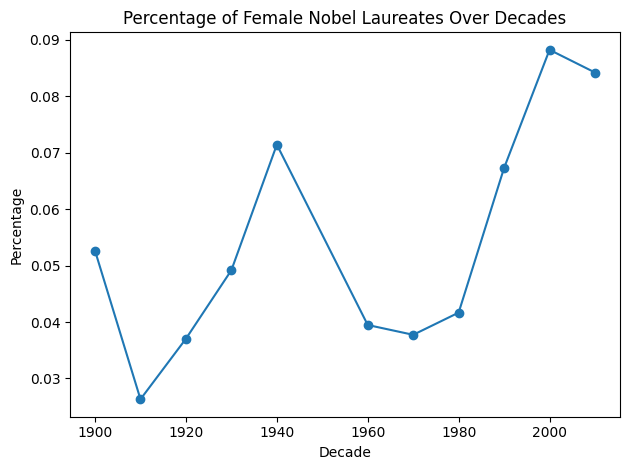

In [14]:
gender_ratio = (
    df_clean.groupby(['Decade', 'Sex'])
    .size()
    .reset_index(name='count')
)

gender_ratio['ratio'] = (
    gender_ratio['count'] /
    gender_ratio.groupby('Decade')['count'].transform('sum')
)

female_ratio = gender_ratio[gender_ratio['Sex'] == 'Female']

plt.plot(female_ratio['Decade'], female_ratio['ratio'], marker='o')
plt.title("Percentage of Female Nobel Laureates Over Decades")
plt.xlabel("Decade")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

This chart shows the female share as a percentage of total prizes per decade, making the
trend clearer than raw counts.
 A rising line means women are winning a larger proportion
of prizes over time, even if the total number of prizes also grew.

**Female Nobel Laureates Over Decades**




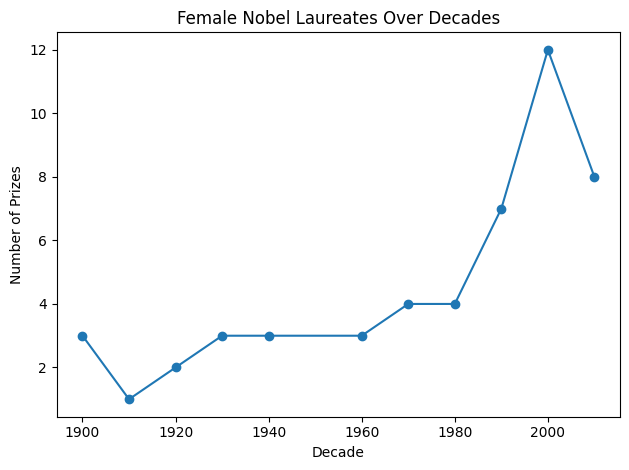

In [39]:
gender_decade_long = (
    df_clean.groupby(['Decade', 'Sex'])
    .size()
    .reset_index(name='count')
)
female_decade = gender_decade_long[gender_decade_long['Sex']=='Female']
female_decade = female_decade.sort_values('Decade')
plt.plot(female_decade['Decade'], female_decade['count'], marker='o')
plt.title("Female Nobel Laureates Over Decades")
plt.xlabel("Decade")
plt.ylabel("Number of Prizes")
plt.tight_layout()
plt.show()

**first female vs first male per category**

            First Male  First Female
Category                            
Chemistry         1901          1911
Economics         1969          2009
Literature        1901          1909
Medicine          1901          1947
Peace             1901          1905
Physics           1901          1903


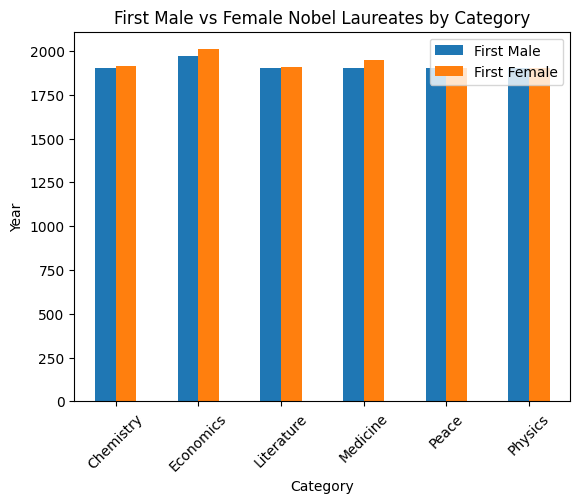

            First Male  First Female  Gap (Years)
Category                                         
Medicine          1901          1947           46
Economics         1969          2009           40
Chemistry         1901          1911           10
Literature        1901          1909            8
Peace             1901          1905            4
Physics           1901          1903            2


In [40]:
male_firsts=(
    df_clean[df_clean['Sex']=='Male']
    .groupby('Category')['Year']
    .min()
)

first_gender_comparison=pd.DataFrame({
   'First Male' : male_firsts,
   'First Female': female_firsts
})
print(first_gender_comparison)

first_gender_comparison.plot(kind='bar')
plt.title("First Male vs Female Nobel Laureates by Category")
plt.xlabel("Category")
plt.ylabel("Year")
plt.xticks(rotation=45)
plt.show()

first_gender_comparison['Gap (Years)']=(
    first_gender_comparison['First Female']-
    first_gender_comparison['First Male']
)
print(first_gender_comparison.sort_values('Gap (Years)', ascending=False))

**Which country has the most winners?**

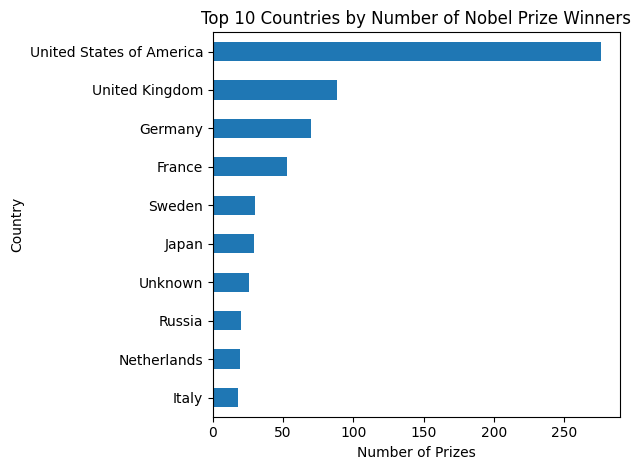

In [33]:
top_countries = df_clean['Birth Country'].value_counts().head(10)

top_countries.sort_values().plot(kind='barh')
plt.title("Top 10 Countries by Number of Nobel Prize Winners")
plt.xlabel("Number of Prizes")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

The United States leads by a wide margin. Keep in mind this counts birth country, not the
country the laureate was working in, so it reflects where winners were born, not
necessarily where the research was done.

**Is there a trend in winning age ?**

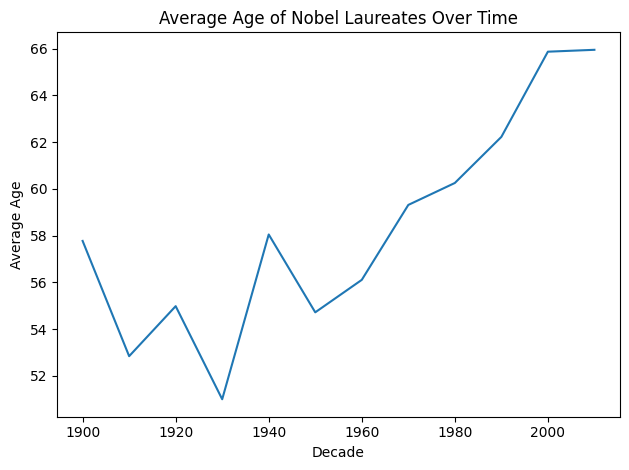

In [30]:
avg_age_per_year = df_clean.groupby('Decade')['Age'].mean()

plt.plot(avg_age_per_year.index, avg_age_per_year.values)

plt.title("Average Age of Nobel Laureates Over Time")
plt.xlabel("Decade")
plt.ylabel("Average Age")

plt.tight_layout()
plt.show()

The average age of Nobel laureates has increased over time. This is likely because
scientific discoveries, especially in Physics, Chemistry, and Medicine, often take
decades to be recognized after the original work was done.

**Conclusion**

This analysis explored Nobel Prize data from 1901 to 2016 across gender, country, and age.

**Gender:** Over 94% of laureates before 1960 were male. Female participation has grown
noticeably since the 1990s, but women still represent a small minority overall. The Peace
and Literature categories were the first to include female winners, while Physics took
until 1903 (Marie Curie) and Economics has the fewest female laureates to date.

**Country:** The United States dominates with significantly more winners than any other
country, followed by the United Kingdom and Germany. This reflects both research
investment and the historical concentration of top universities.

**Age:** The average winning age has risen from roughly 50 in the early 1900s to over 65
in recent decades, suggesting that groundbreaking work is increasingly recognized long
after it is completed.

**Overall,** the data reveals a gradual but clear shift toward greater diversity in Nobel Prize
history, though gender imbalance remains significant